In [2]:
import bioread
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [40]:
def check_data_labeling(pid):
    pid = str(pid)
    acq_file_path = f"data/01_raw/{pid}/{pid}.acq"
    conditions_file_path = f"data/01_raw/{pid}/conditions.csv"
    fast_csv_path = f"data/01_raw/{pid}/fast.csv"


    acq_data = bioread.read_file(acq_file_path)

    zyg_channel = None
    active_trigger = None

    for channel in acq_data.channels:
        channel_name = channel.name.lower()
        print(f"- {channel.name}")
        if int(pid) > 13:
            if 'emg1' in channel_name or 'emg a' in channel_name:
                zyg_channel = channel
                continue
            if 'trigger_1' in channel_name:
                if np.max(channel.data) > 0.5:
                    active_trigger = channel
            
                
        else:
            if 'zyg' in channel_name:
                zyg_channel = channel
                continue
            if 'trial' in channel_name:
                if np.max(channel.data) > 0.5:
                    active_trigger = channel
            

    print(active_trigger)

    raw_time = zyg_channel.time_index
    raw_zyg = zyg_channel.data
    fs = zyg_channel.samples_per_second
    

    conditions_df = pd.read_csv(conditions_file_path)
    fast_condition_row = conditions_df[conditions_df['Condition'].str.lower() == 'fast']
    fast_order = fast_condition_row['Order'].values[0]


    fast_df = pd.read_csv(fast_csv_path)
    zyg_col_name = [col for col in fast_df.columns if 'zygomaticus_emg' in col.lower()][0]
    extracted_zyg = fast_df[zyg_col_name].values

    trig_data = active_trigger.data
    trig_time = active_trigger.time_index
    thresh = np.max(trig_data) / 2.0
    is_high = trig_data > thresh
    diff = np.diff(is_high.astype(int))
    onsets = trig_time[np.where(diff == 1)[0]]
    offsets = trig_time[np.where(diff == -1)[0]]
    print(onsets)
    if len(onsets) >= 4:
        trig_idx = 1 if fast_order == 2 else 2
    else:
        trig_idx = 1 if fast_order == 2 else 3

    onset_sec = onsets[trig_idx]
    offset_sec = offsets[trig_idx]
    duration_sec = offset_sec - onset_sec
    duration_min = duration_sec / 60.0
    print(duration_sec, duration_min)
    extracted_time = np.linspace(onset_sec, offset_sec, len(extracted_zyg))
    print(extracted_time)

    plt.figure(figsize=(15, 6))

    plt.plot(raw_time, raw_zyg, label='Raw ACQ EMG-Zyg', color='#1f77b4', alpha=0.8)

    plt.axvspan(onset_sec, offset_sec, color='#ff7f0e', alpha=0.3, label=f'Fast Condition (Order: {fast_order})')

    plt.plot(extracted_time, extracted_zyg + 0.1, label='fast.csv (Extracted) + 0.1 Offset', color='#d62728', linewidth=1.5)

    plt.title(f"Data Labeling Check: Participant {pid}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

- Zygomaticus fEMG , 5 - 1000 Hz
- Corrugator fEMG , 5 - 1000 Hz
- ECG (.05 - 150 Hz)
- Respiration
- Trial
Channel Trial: 3390200 samples, 2000.0 samples/sec, loaded: True
[  18.60650549  473.40263964 1089.01982123 1431.97692239]
307.8230907979148 5.130384846631913
[473.40263964 473.40313964 473.40363964 ... 781.22473043 781.22523044
 781.22573044]


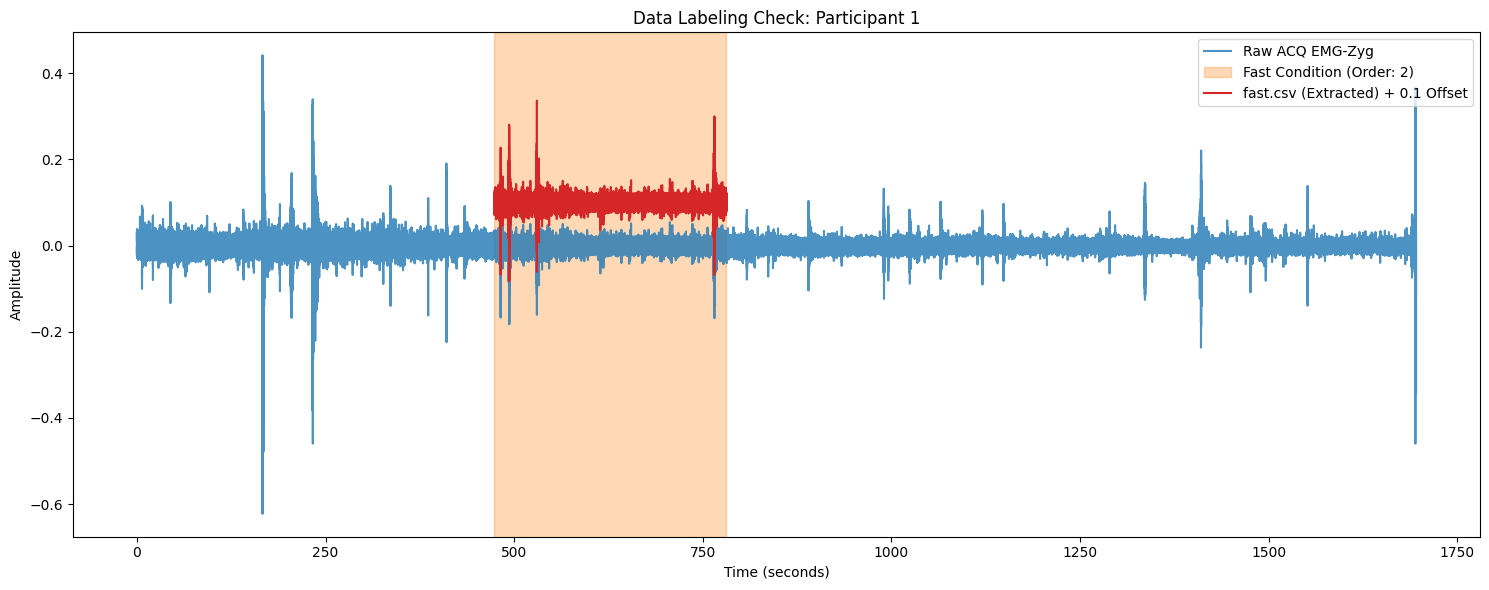

In [33]:
check_data_labeling(1)

- Zygomaticus fEMG , 5 - 1000 Hz
- Corrugator fEMG , 5 - 1000 Hz
- ECG (.05 - 150 Hz)
- Respiration
- Trial
Channel Trial: 4416770 samples, 2000.0 samples/sec, loaded: True
[  21.40600485 1199.47927157 1815.47891104 2157.1334884 ]
307.82256969404557 5.130376161567426
[1815.47891104 1815.47941104 1815.47991104 ... 2123.30048073 2123.30098074
 2123.30148074]


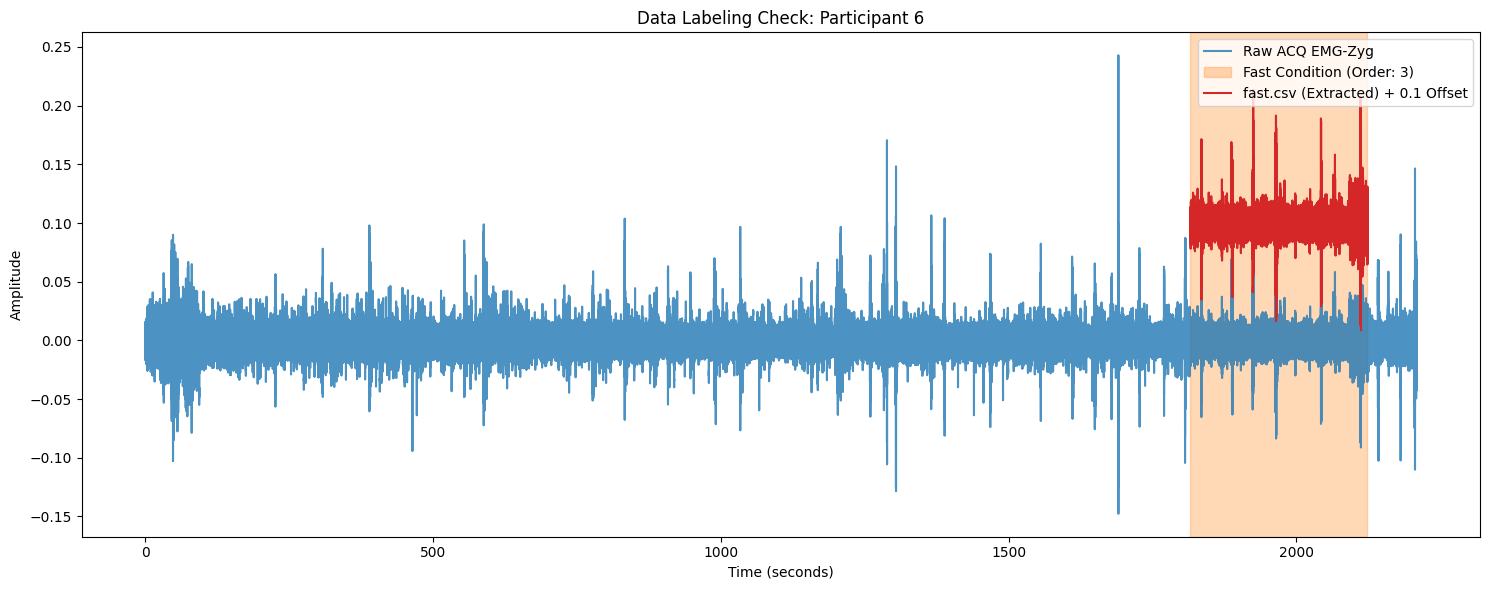

In [34]:
check_data_labeling(6)

- Zygomaticus fEMG , 5 - 1000 Hz
- Corrugator fEMG , 5 - 1000 Hz
- ECG (.05 - 150 Hz)
- Respiration
- Trial
Channel Trial: 3861660 samples, 2000.0 samples/sec, loaded: True
[  76.05001969  652.31666892 1531.61589662 1873.91848526]
307.8200797118543 5.1303346618642385
[1531.61589662 1531.61639662 1531.61689662 ... 1839.43497633 1839.43547633
 1839.43597633]


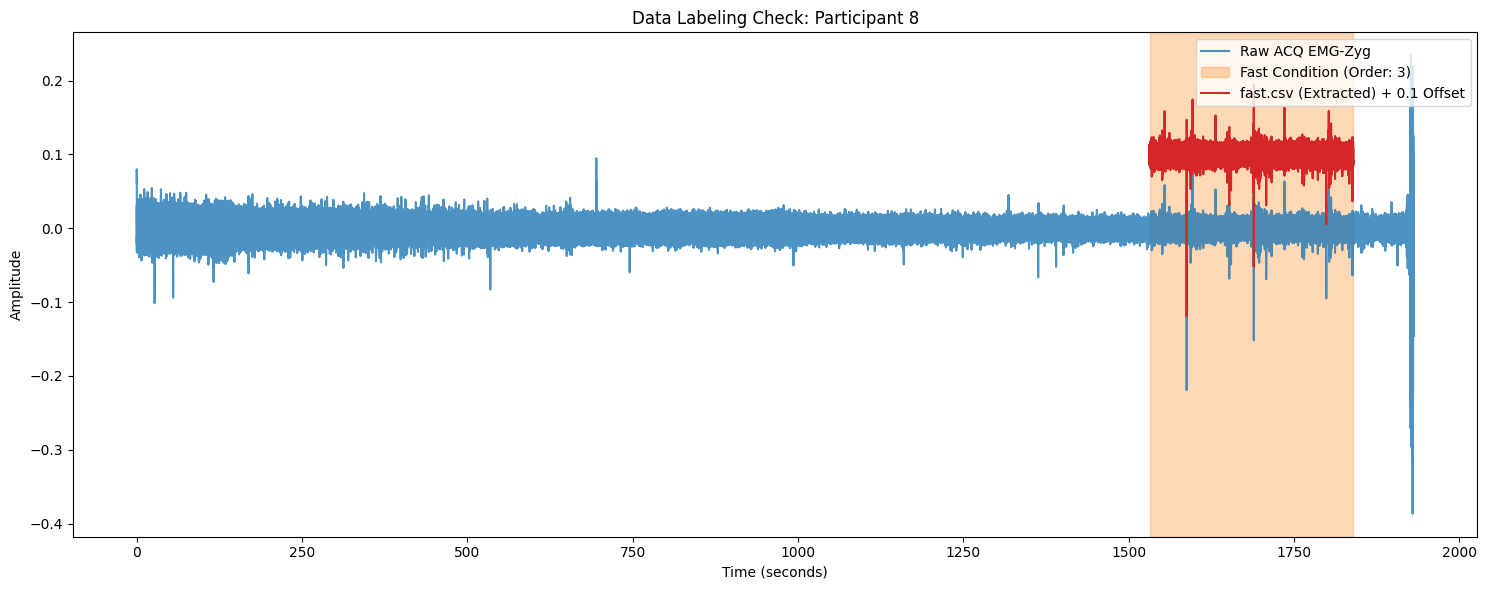

In [35]:
check_data_labeling(8)

- EMG A, X, EMG2-R
- RSP A, X, RSP2-R
- EMG B, X, EMG2-R
- RSP B, X, RSP2-R
- Trigger_0
- Trigger_1
- Trigger_2
- Trigger_3
- Trigger_4
- Trigger_5
- Trigger_6
- Trigger_7
Channel Trigger_1: 3498780 samples, 2000.0 samples/sec, loaded: True
[  28.90850826  633.88018117 1351.19488619 1698.22448538]
307.8180879786919 5.130301466311532
[1351.19488619 1351.19538619 1351.19588619 ... 1659.01197417 1659.01247417
 1659.01297417]


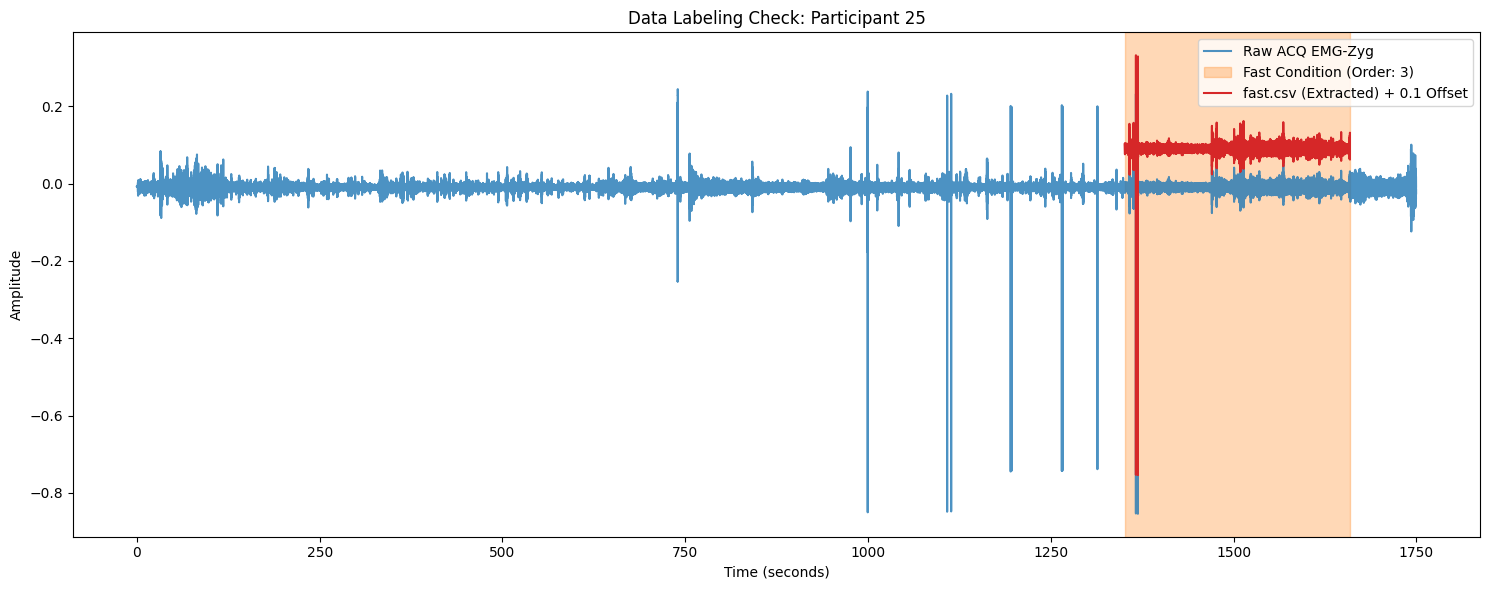

In [41]:
check_data_labeling(25)

- EMG A, X, EMG2-R
- RSP A, X, RSP2-R
- EMG B, X, EMG2-R
- RSP B, X, RSP2-R
- Trigger_0
- Trigger_1
- Trigger_2
- Trigger_3
- Trigger_4
- Trigger_5
- Trigger_6
- Trigger_7
Channel Trigger_1: 3234553 samples, 2000.0 samples/sec, loaded: True
[  49.25751523  518.03416016 1278.26239519]
307.8245951675842 5.130409919459737
[518.03416016 518.03466016 518.03516016 ... 825.85775532 825.85825532
 825.85875532]


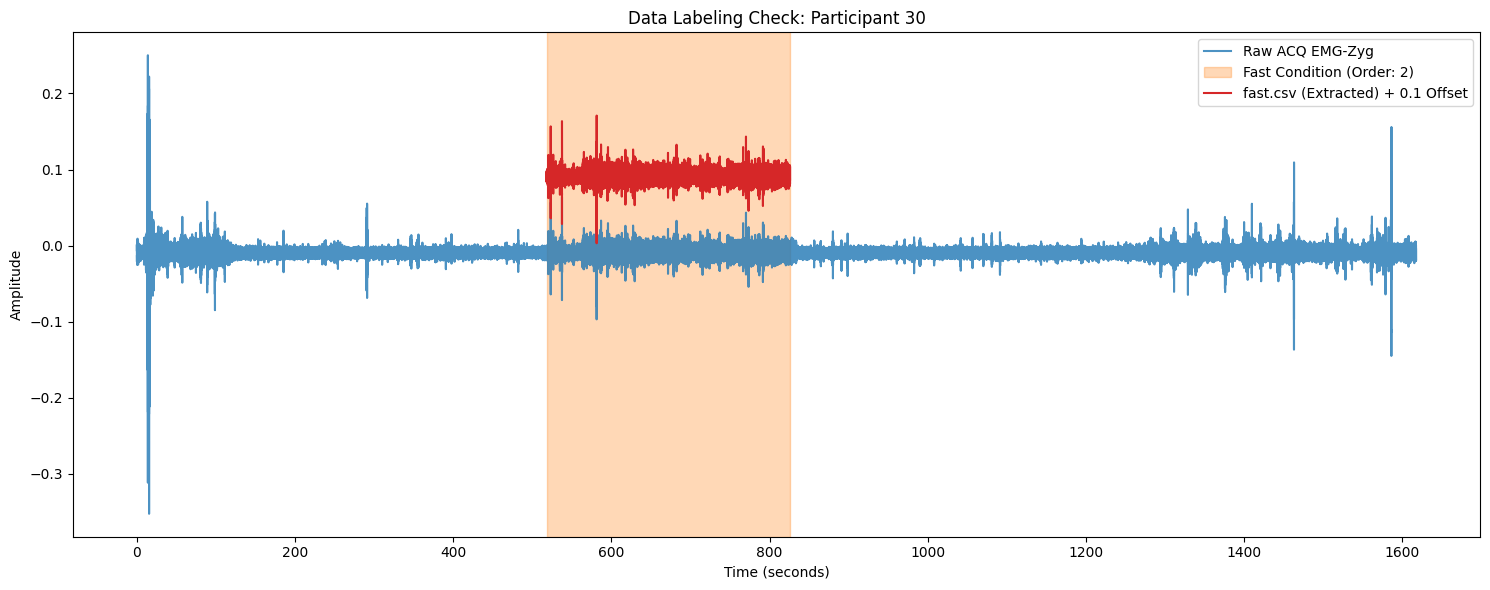

In [42]:
check_data_labeling(30)

- EMG A, X, EMG2-R
- RSP A, X, RSP2-R
- EMG B, X, EMG2-R
- RSP B, X, RSP2-R
- Trigger_0
- Trigger_1
- Trigger_2
- Trigger_3
- Trigger_4
- Trigger_5
- Trigger_6
- Trigger_7
Channel Trigger_1: 4117165 samples, 2000.0 samples/sec, loaded: True
[  97.63652371  563.69763691 1639.29989816 1985.38698222]
308.54007493993436 5.142334582332239
[563.69763691 563.69813779 563.69863867 ... 872.2367101  872.23721098
 872.23771185]


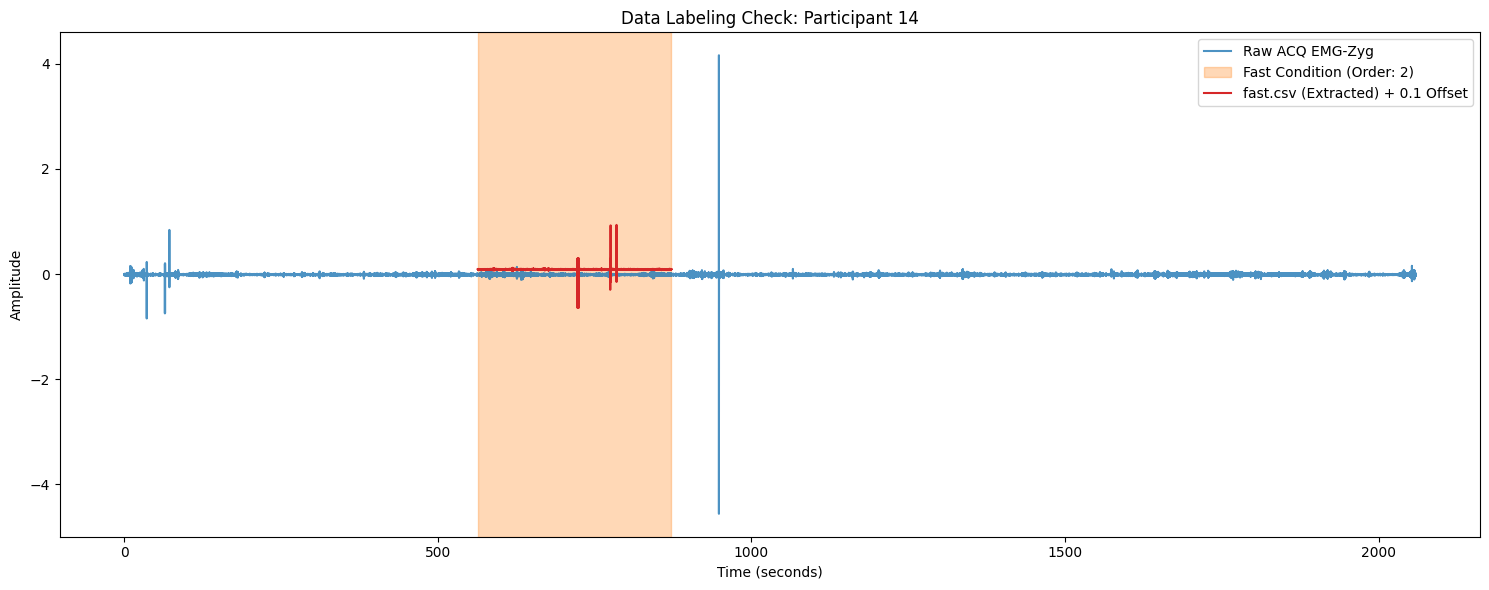

In [46]:
check_data_labeling(14)

- EMG A, X, EMG2-R
- RSP A, X, RSP2-R
- EMG B, X, EMG2-R
- RSP B, X, RSP2-R
- Trigger_0
- Trigger_1
- Trigger_2
- Trigger_3
- Trigger_4
- Trigger_5
- Trigger_6
- Trigger_7
Channel Trigger_1: 3672648 samples, 2000.0 samples/sec, loaded: True
[ 122.26203329  591.96866118 1415.50288542 1767.58748128]
308.53658400929885 5.142276400154981
[1415.50288542 1415.50338629 1415.50388716 ... 1724.03846768 1724.03896855
 1724.03946943]


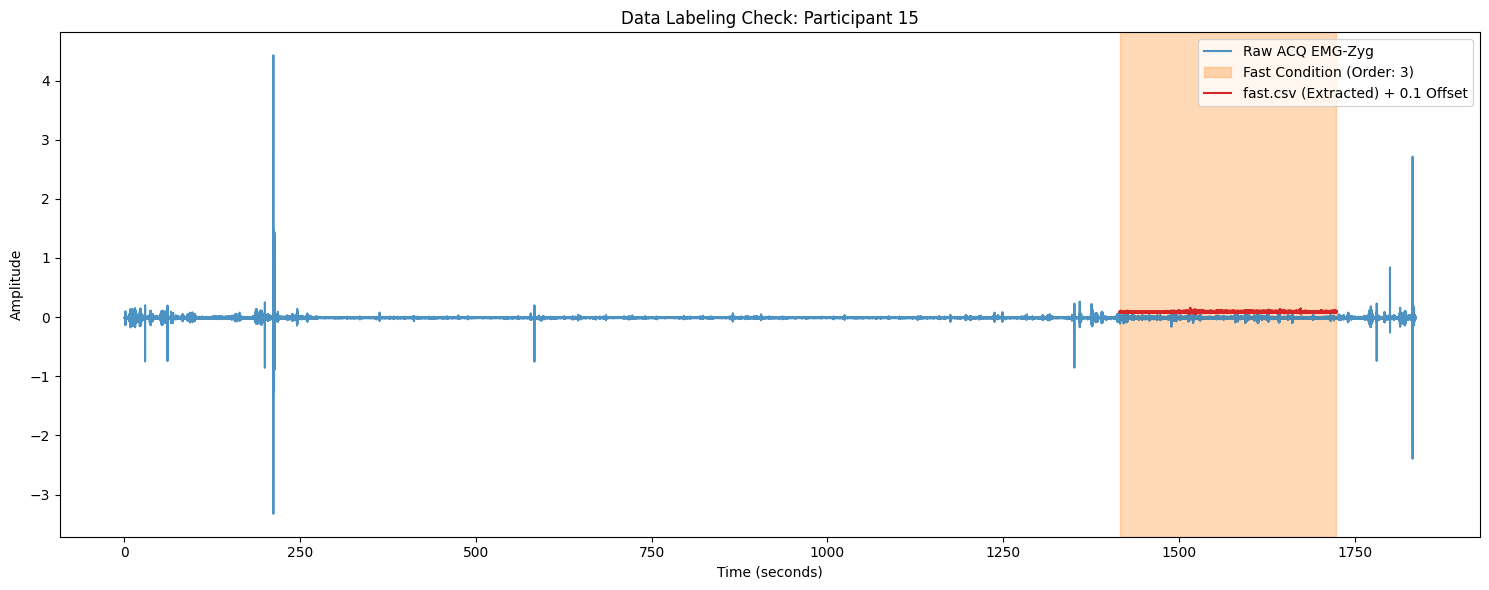

In [47]:
check_data_labeling(15)

In [49]:
check_data_labeling(16)

- EMG A, X, EMG2-R
- RSP A, X, RSP2-R
- EMG B, X, EMG2-R
- RSP B, X, RSP2-R
- Trigger_0
- Trigger_1
- Trigger_2
- Trigger_3
- Trigger_4
- Trigger_5
- Trigger_6
- Trigger_7
None


AttributeError: 'NoneType' object has no attribute 'data'

In [50]:
def plot_all_triggers(pid):
    pid = str(pid)
    acq_file_path = f"data/01_raw/{pid}/{pid}.acq"
    
    acq_data = bioread.read_file(acq_file_path)

    trigger_channels = [ch for ch in acq_data.channels if 'trigger_1' in ch.name.lower()]

    num_triggers = len(trigger_channels)
    fig, axes = plt.subplots(num_triggers, 1, figsize=(15, 2 * num_triggers), sharex=True)
    
    if num_triggers == 1:
        axes = [axes]

    for i, ch in enumerate(trigger_channels):
        axes[i].plot(ch.time_index, ch.data, color='#2ca02c')
        axes[i].set_ylabel(ch.name, rotation=0, labelpad=40, ha='right')
        
        y_min, y_max = min(ch.data), max(ch.data)
        if y_max - y_min < 1:
            axes[i].set_ylim(y_min - 1, y_max + 1)
            
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (seconds)")
    fig.suptitle(f"Hardware Triggers Check: Participant {pid}", fontsize=14)
    plt.tight_layout()
    plt.show()

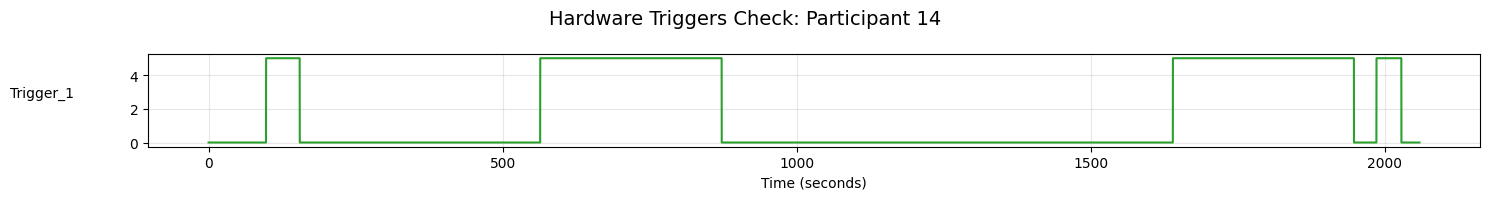

In [52]:
plot_all_triggers(14)

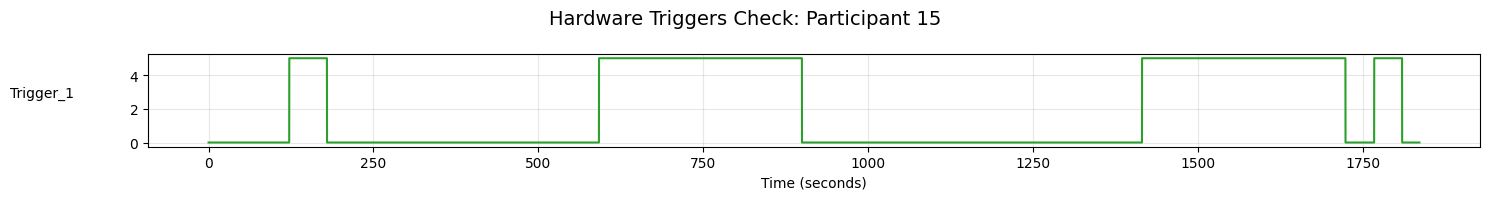

In [53]:
plot_all_triggers(15)

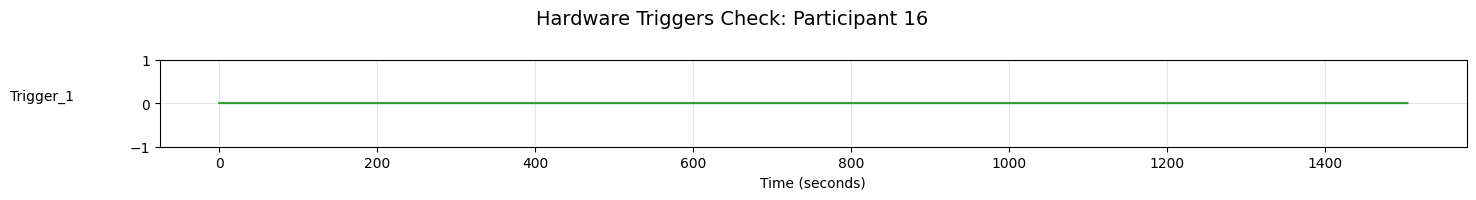

In [54]:
plot_all_triggers(16)

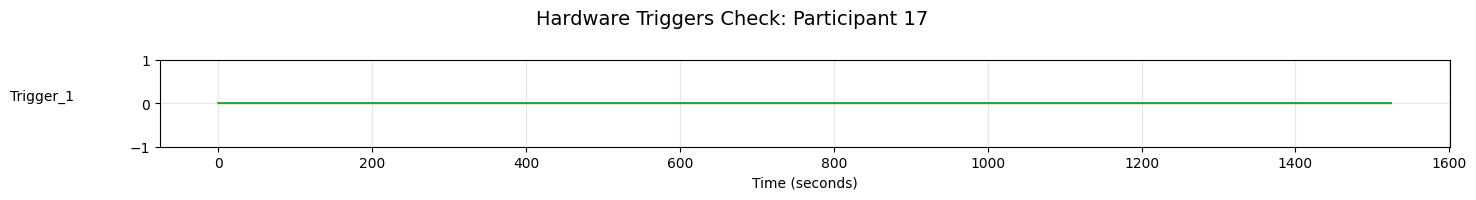

In [55]:
plot_all_triggers(17)

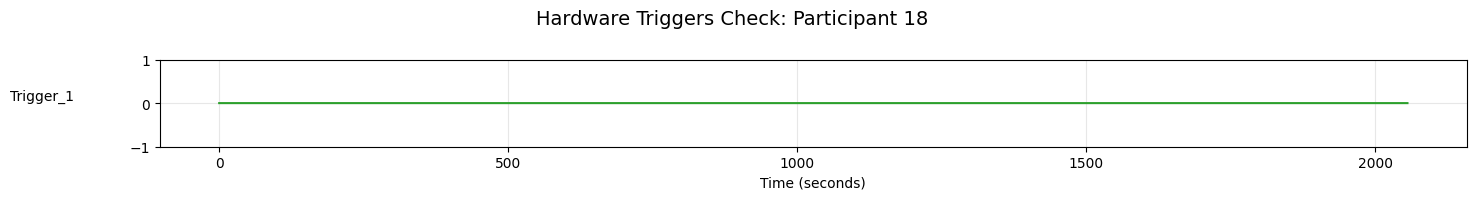

In [56]:
plot_all_triggers(18)

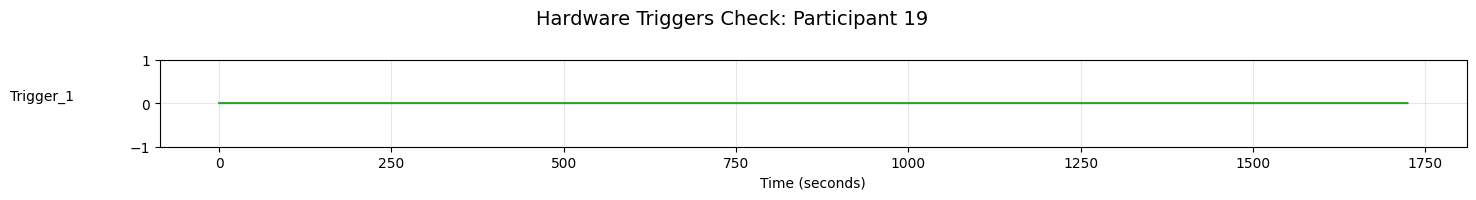

In [57]:
plot_all_triggers(19)

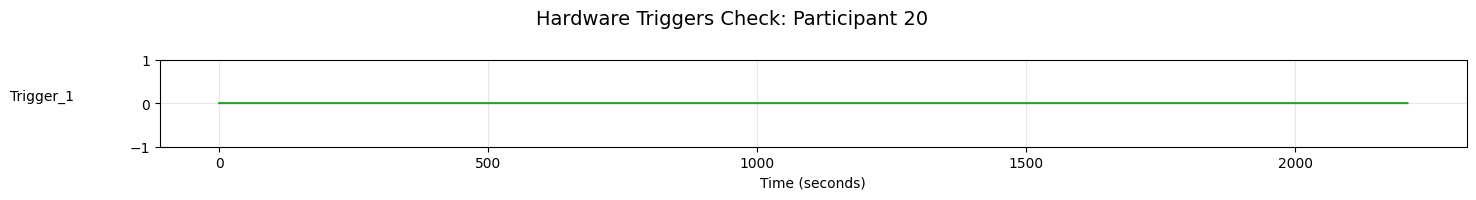

In [58]:
plot_all_triggers(20)

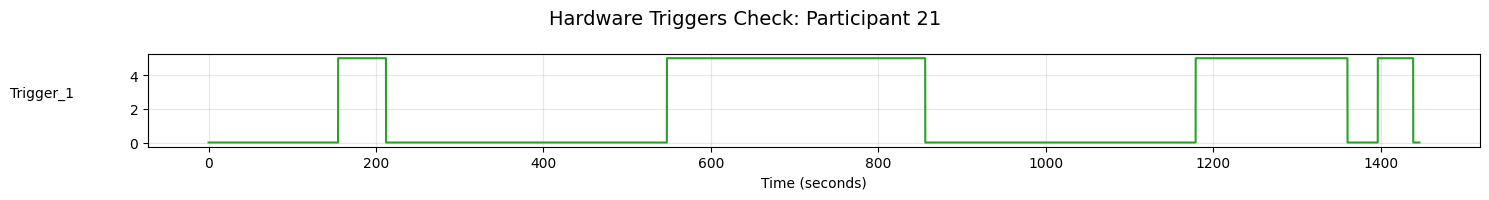

In [59]:
plot_all_triggers(21)

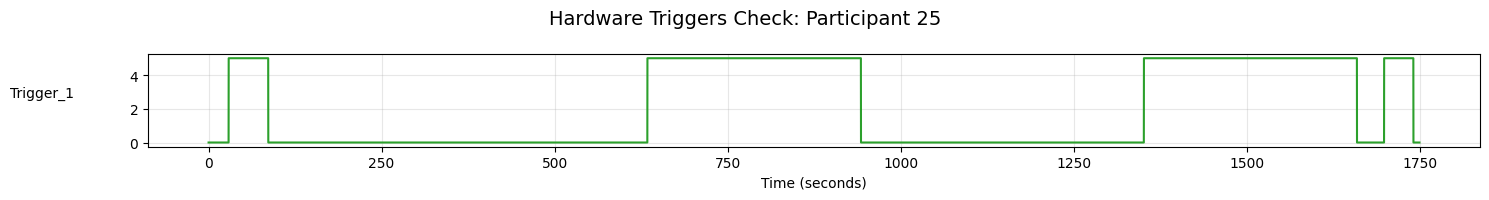

In [60]:
plot_all_triggers(25)

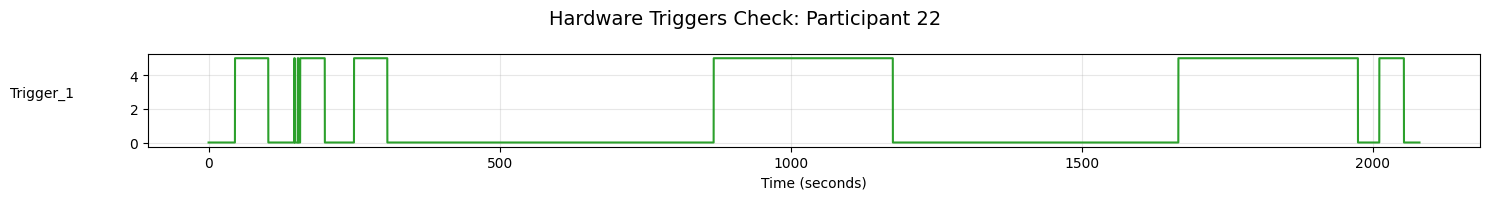

In [61]:
plot_all_triggers(22)

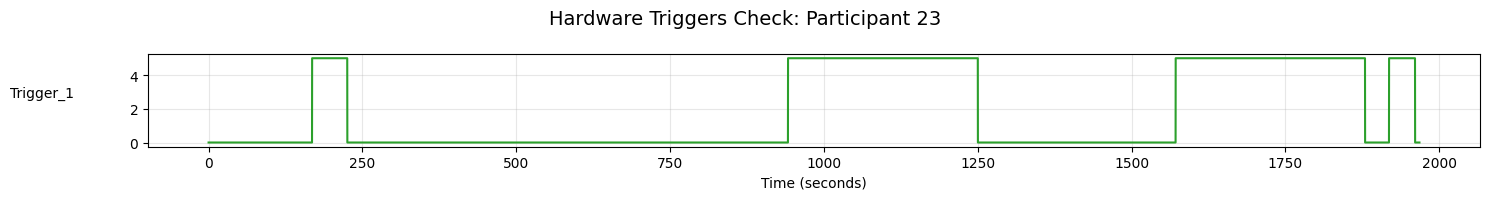

In [62]:
plot_all_triggers(23)

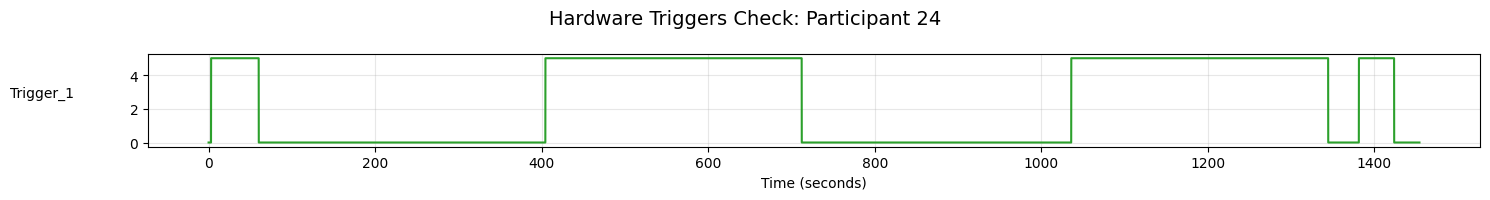

In [63]:
plot_all_triggers(24)

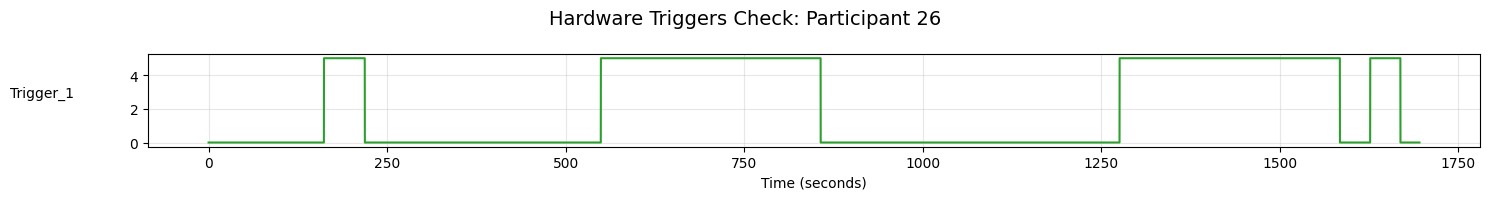

In [64]:
plot_all_triggers(26)

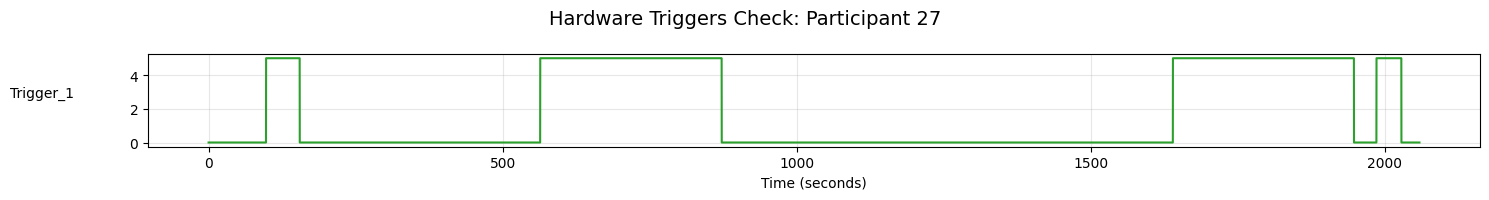

In [65]:
plot_all_triggers(27)

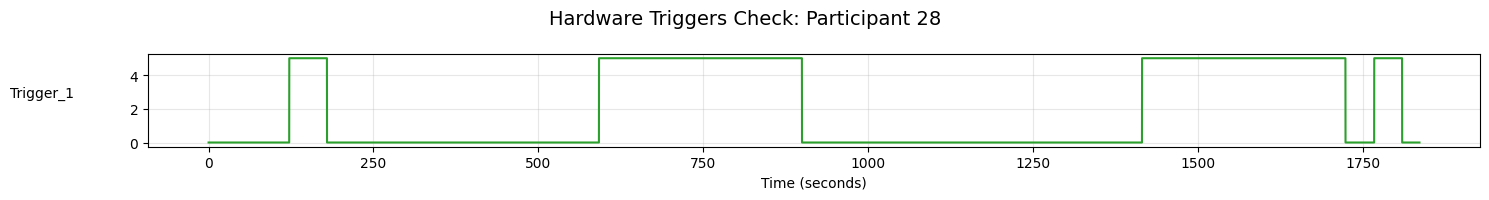

In [66]:
plot_all_triggers(28)

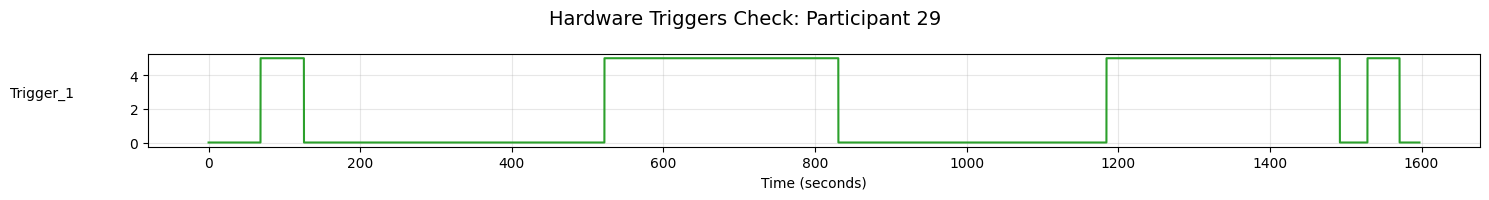

In [67]:
plot_all_triggers(29)

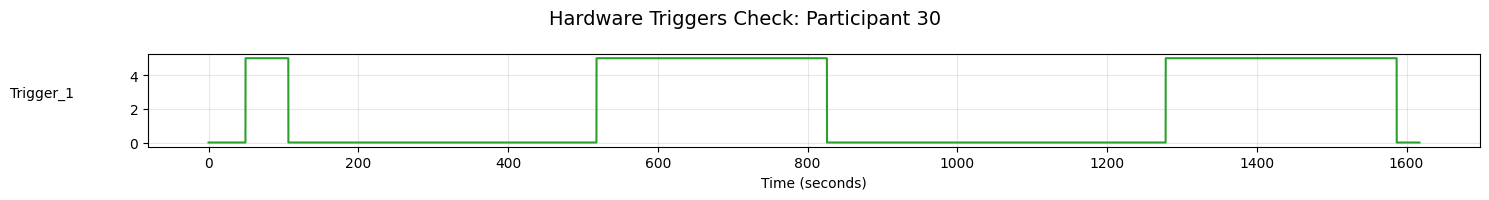

In [68]:
plot_all_triggers(30)

In [69]:


def check_total_duration(pid):
    pid = str(pid)
    acq_file_path = f"data/01_raw/{pid}/{pid}.acq"
    
    acq_data = bioread.read_file(acq_file_path)
    
    first_channel = acq_data.channels[0]
    total_seconds = first_channel.time_index[-1]
    total_minutes = total_seconds / 60.0
    
    print(f"Participant {pid} - Total Recording Time: {total_seconds:.2f} seconds ({total_minutes:.2f} minutes)")


In [72]:

check_total_duration(18)

Participant 18 - Total Recording Time: 2055.93 seconds (34.27 minutes)
